In [1]:
from ryp import r, to_py

import liesel_gam as gam

In [2]:
r("library(mgcv)")
r("data(columb)")
columb = to_py("columb", format="pandas")

Loading required package: nlme
This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.


In [3]:
from liesel_gam.term import StrctTensorProdTerm

In [4]:
tb = gam.TermBuilder.from_df(columb)

s = tb.ps(
    "x",
    k=5,
    absorb_cons=False,
    diagonal_penalty=False,
    scale_penalty=False,
)

sy = tb.ps(
    "y",
    k=5,
    absorb_cons=False,
    diagonal_penalty=False,
    scale_penalty=False,
)

tf = StrctTensorProdTerm(s, sy)

W0419 22:54:21.195934 37163379 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


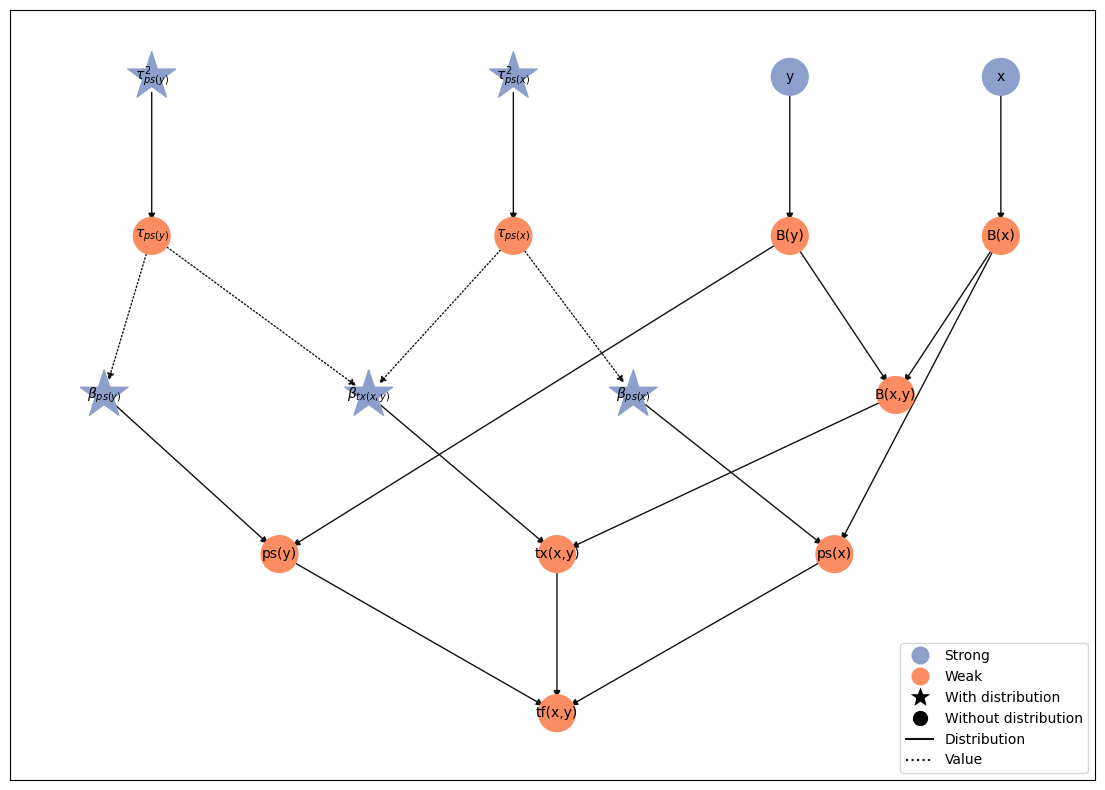

In [5]:
tf.plot_vars()

In [6]:
tb = gam.TermBuilder.from_df(columb)

s = tb.ps("x", k=5)
sy = tb.ps("y", k=5)
sz = tb.ps("area", k=5)

s.scale.value_node[0].inference = None
tf = StrctTensorProdTerm(s, sy, sz)

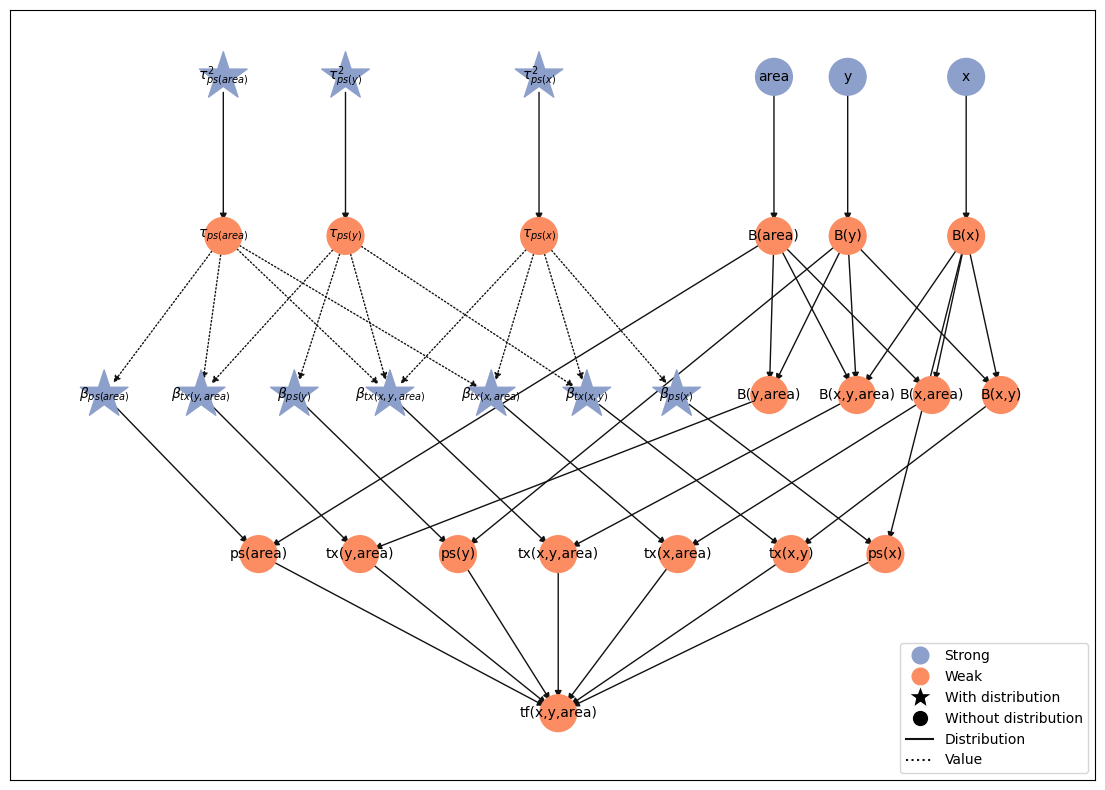

In [7]:
tf.plot_vars()

In [8]:
tb = gam.TermBuilder.from_df(columb)

s = tb.ps("x", k=5)
sy = tb.ps("y", k=5)
sz = tb.ps("area", k=5)

s.scale.value_node[0].inference = None
tf = StrctTensorProdTerm(s, sy, sz, group_terms_by_order=True)

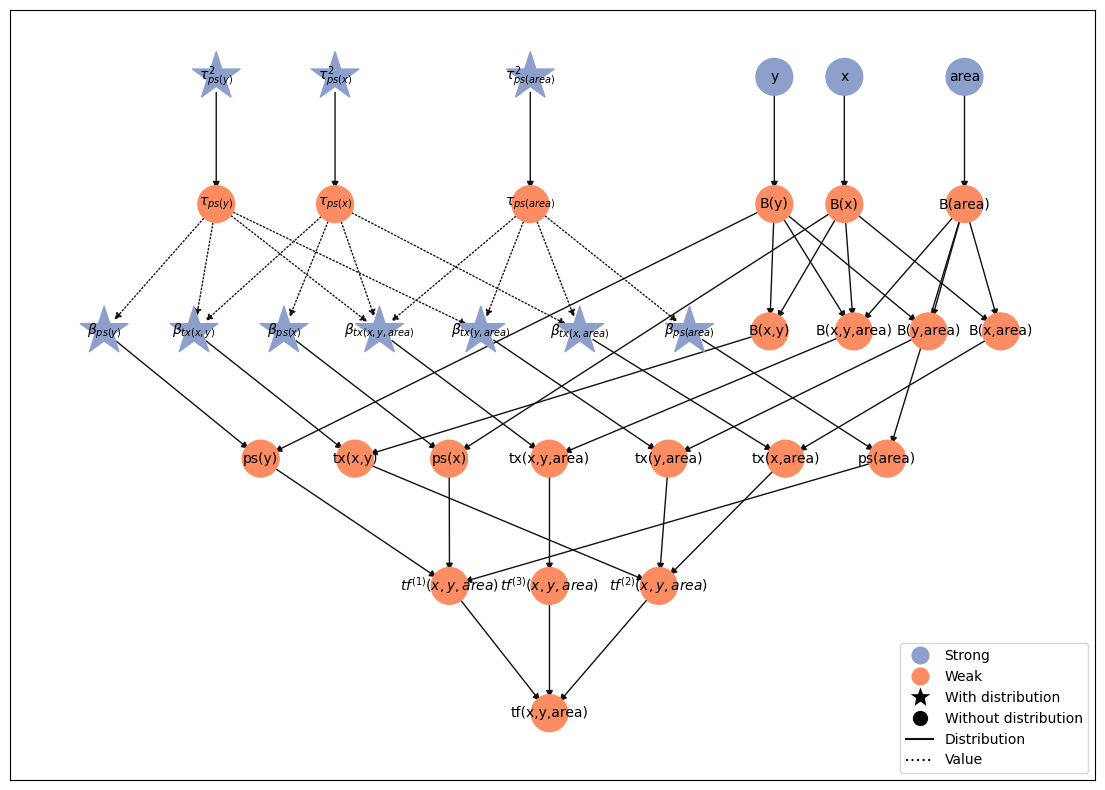

In [9]:
tf.plot_vars()